# **Study of Income in Denmark**

Sanchini Federico -
24/01/2024


This notebook presents a study of income trends among Danish citizens, divided into three main groups: families, couples, and single people.

The analysis focuses on the changes that occurred between 2014 and 2023, especially the percentage variations of the groups belonging to each income bracket. This is accompanied by a study of the **Gini coefficient**, in order to check whether these changes led to a reduction in economic inequality.

Finally, the notebook analyzes the **geographical distribution of wealth**, highlighting the concentration of particularly wealthy groups in specific areas of Denmark. In particular, the *Capital Region* is examined.


In [1]:
import warnings
import pandas as pd

# Silence warnings in the notebook
warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load the CSV file
file_path = 'family_income_dk2014-2023.csv'
df = pd.read_csv(file_path)

df.head()


,c1,c2,c3,place,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Families in the group (Number),Total,"Families, total",All Denmark,2882246,2913147,2943524,2973031,2995484,3014327,3042302,3066273,3087026,3118634
1,Families in the group (Number),Total,"Families, total",Copenhagen,343970,349454,354843,360914,366895,371417,377095,381659,384503,388467
2,Families in the group (Number),Total,"Families, total",Frederiksberg,60036,60418,60653,60256,59846,59789,59842,60114,60472,60701
3,Families in the group (Number),Total,"Families, total",Dragør,6464,6501,6583,6628,6638,6746,6776,6791,6722,6742
4,Families in the group (Number),Total,"Families, total",Tårnby,20869,21050,21193,21261,21241,21235,21137,21191,21230,21660


In [2]:
# Remove the first column
df = df.drop(columns=['c1'])

# Rename the columns
df = df.rename(columns={'c2': 'income', 'c3': 'group'})

# Replace the values in the 'group' column
df['group'] = df['group'].replace({
    'Families, total': 'Families',
    'Couples, total': 'Couples',
    'Single people, total': 'Single'
})

# Replace the values in the 'income' column
df['income'] = df['income'].replace({
    'Less than 200,000 DKK': '<200k',
    '200,000 - 299,999 DKK': '200k-299k',
    '300,000 - 399,999 DKK': '300k-399k',
    '400,000 - 499,999 DKK': '400k-499k',
    '500,000 - 599,999 DKK': '500k-599k',
    '600,000 - 699,999 DKK': '600k-699k',
    '700,000 - 799,000 DKK': '700k-799k',
    '800,000 - 899,000 DKK': '800k-899k',
    '900,000 - 999,000 DKK': '900k-999k',
    '1 million DKK, and more': '>1M',
})

output_file_path = 'family_income_modified.csv'  # Specify the path and file name
df.to_csv(output_file_path, index=False)  # `index=False` prevents saving the index as a column

print(df.dtypes)


income    object
group     object
place     object
2014      object
2015      object
2016      object
2017      object
2018      object
2019      object
2020      object
2021      object
2022      object
2023      object
dtype: object


In [3]:
# List of columns to convert
columns_to_convert = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

# Convert the columns to numeric values, replacing invalid values with NaN
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# Variations across income brackets

For each group in the original file (families, couples, and single people), the percentage of entities in a given income bracket is calculated relative to the total. This is done for two different years, 2014 and 2023, namely the first and last available years.

By calculating the difference between the percentages for each bracket, it is possible to observe the "migration" of some entities toward other income brackets and to understand the overall trend.


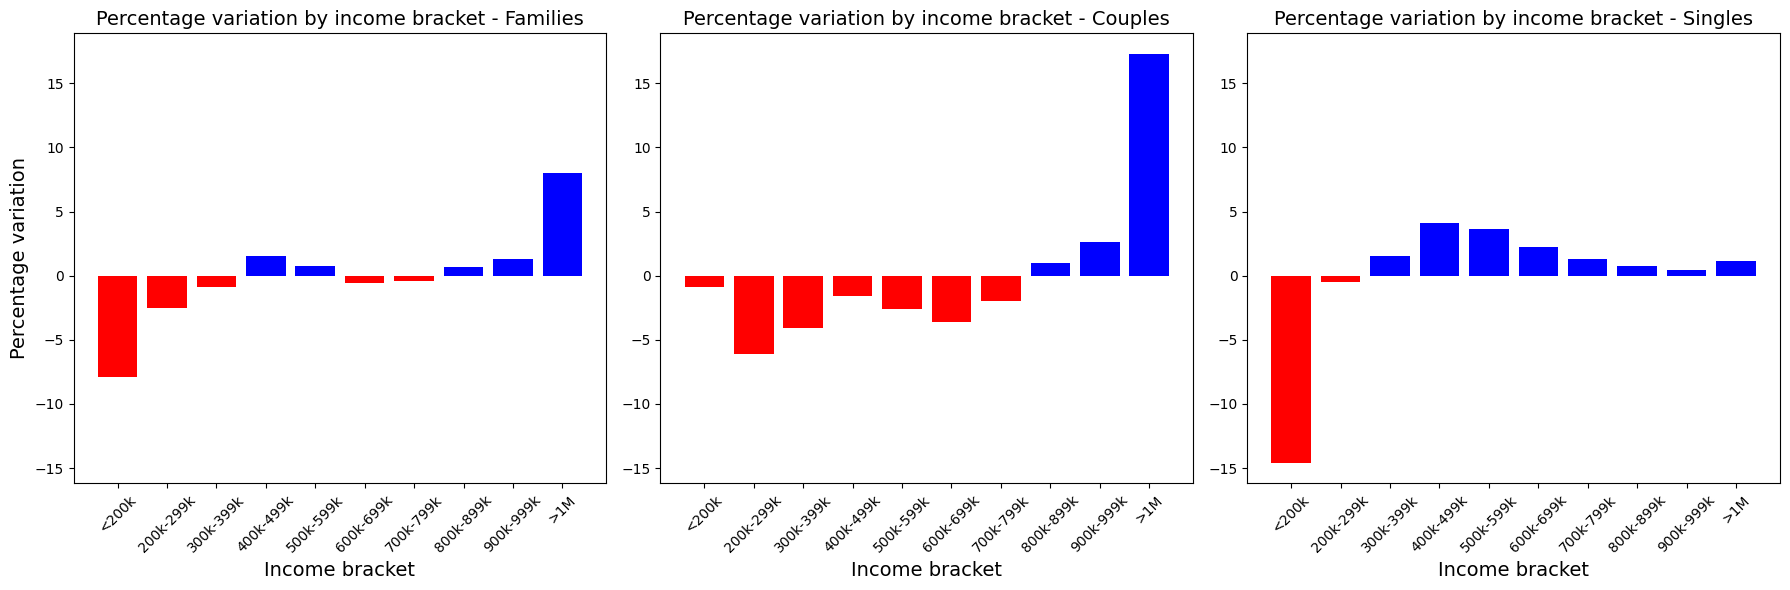

In [4]:
# Filter to select only rows with 'All Denmark' in the 'place' column
df_all_denmark = df[df['place'] == 'All Denmark']

# Filter the data for each group
families_data = df_all_denmark[df_all_denmark['group'] == 'Families'].copy()
couples_data = df_all_denmark[df_all_denmark['group'] == 'Couples'].copy()
singles_data = df_all_denmark[df_all_denmark['group'] == 'Single'].copy()

# Calculate percentage variations
families_data.loc[:, "% 2014"] = (families_data["2014"] / families_data.loc[families_data['income'] == 'Total', '2014'].values[0]) * 100
families_data.loc[:, "% 2023"] = (families_data["2023"] / families_data.loc[families_data['income'] == 'Total', '2023'].values[0]) * 100
families_data.loc[:, "% variation"] = families_data["% 2023"] - families_data["% 2014"]

couples_data.loc[:, "% 2014"] = (couples_data["2014"] / couples_data.loc[couples_data['income'] == 'Total', '2014'].values[0]) * 100
couples_data.loc[:, "% 2023"] = (couples_data["2023"] / couples_data.loc[couples_data['income'] == 'Total', '2023'].values[0]) * 100
couples_data.loc[:, "% variation"] = couples_data["% 2023"] - couples_data["% 2014"]

singles_data.loc[:, "% 2014"] = (singles_data["2014"] / singles_data.loc[singles_data['income'] == 'Total', '2014'].values[0]) * 100
singles_data.loc[:, "% 2023"] = (singles_data["2023"] / singles_data.loc[singles_data['income'] == 'Total', '2023'].values[0]) * 100
singles_data.loc[:, "% variation"] = singles_data["% 2023"] - singles_data["% 2014"]

families_data = families_data[families_data['income'] != 'Total']
couples_data = couples_data[couples_data['income'] != 'Total']
singles_data = singles_data[singles_data['income'] != 'Total']

output_file_path = 'family.csv'  # Specify the path and file name
families_data.to_csv(output_file_path, index=False)  # `index=False` prevents saving the index as a column

import matplotlib.pyplot as plt

# Create a figure with 3 subplots (1 row, 3 columns), sharing the y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Custom font sizes
title_fontsize = 14
label_fontsize = 14
tick_fontsize = 10

# Filter and create the histogram for the Families group
colors_families = ['blue' if x >= 0 else 'red' for x in families_data['% variation']]
axes[0].bar(families_data['income'], families_data['% variation'], color=colors_families)
axes[0].set_xlabel('Income bracket', fontsize=label_fontsize)
axes[0].set_ylabel('Percentage variation', fontsize=label_fontsize)
axes[0].set_title('Percentage variation by income bracket - Families', fontsize=title_fontsize)
axes[0].tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
axes[0].tick_params(axis='y', labelsize=tick_fontsize)

# Filter and create the histogram for the Couples group
colors_couples = ['blue' if x >= 0 else 'red' for x in couples_data['% variation']]
axes[1].bar(couples_data['income'], couples_data['% variation'], color=colors_couples)
axes[1].set_xlabel('Income bracket', fontsize=label_fontsize)
axes[1].set_title('Percentage variation by income bracket - Couples', fontsize=title_fontsize)
axes[1].tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
axes[1].tick_params(axis='y', labelsize=tick_fontsize)

# Filter and create the histogram for the Singles group
colors_singles = ['blue' if x >= 0 else 'red' for x in singles_data['% variation']]
axes[2].bar(singles_data['income'], singles_data['% variation'], color=colors_singles)
axes[2].set_xlabel('Income bracket', fontsize=label_fontsize)
axes[2].set_title('Percentage variation by income bracket - Singles', fontsize=title_fontsize)
axes[2].tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
axes[2].tick_params(axis='y', labelsize=tick_fontsize)

# Add y-axis tick labels to each subplot
for ax in axes:
    ax.yaxis.set_tick_params(which='both', labelleft=True)

# Optimize the layout to avoid overlaps
plt.tight_layout()

# Show the figure with the 3 plots
plt.show()


The choice of considering the difference between the percentages of each income bracket, rather than the percentage change within each bracket, is necessary because the total number of tax declarations increased from 2014 to 2023. This would otherwise introduce a hidden increase in the percentage variation.

For each group considered (families, couples, and single people), the sum of the percentage variations across all income brackets is 0.

Mathematically, this represents the "migration" of entities belonging to a given group from one income bracket to another, normalized by the total number of entities.

Overall, as shown by the three plots, the percentage variations of the lower income brackets are negative, highlighting a relative decrease in less wealthy entities. As a consequence, the higher income brackets show positive percentage variations, corresponding to a relative increase in entities belonging to wealthier brackets.


# Gini coefficient

The increase in entities belonging to higher income brackets and the decrease in lower income brackets suggest a process of economic redistribution and a consequent reduction in income inequality among Danish citizens.

To verify whether this is actually the case, the **Gini coefficient** can be calculated year by year.

The Gini coefficient, introduced by the Italian statistician Corrado Gini, is a measure of inequality in a distribution. It is a number between 0 and 1. Low values indicate a fairly homogeneous distribution, with 0 corresponding to perfect equality, for example a situation in which everyone receives exactly the same income. High values indicate a more unequal distribution, with 1 corresponding to maximum concentration, namely a situation in which one person receives all the income of the country while everyone else has zero income.

The mathematical definition of the Gini coefficient is based on the Lorenz curve of the distribution and is related to the area between the line of perfect equality and the Lorenz curve. The Gini coefficient is defined as the ratio between the area between the line of perfect equality and the Lorenz curve, $A$, and the total area under the line of perfect equality, $A + B$:

$$G = A / ( A + B )$$


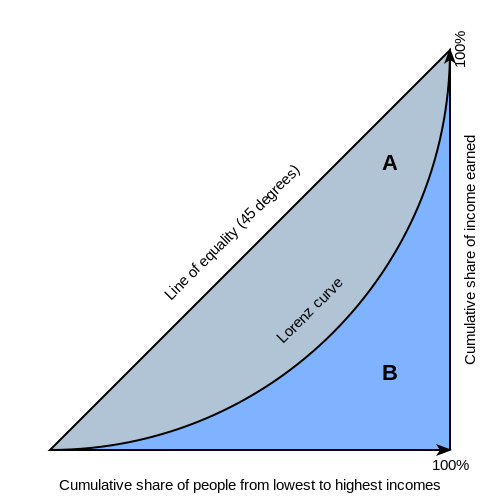

In [5]:
# Load and display the PNG image
from IPython.display import display, Image
display(Image(filename='Gini_definizione.png', width=600))


In some cases, the entire Lorenz curve may not be known, and only the values at certain intervals may be available. In this case, the Gini coefficient can be approximated using several interpolation techniques to estimate the missing values of the Lorenz curve.

If the known points on the Lorenz curve are given as $(X_k, Y_k)$, where the values of $X_k$ are indexed in increasing order (that is, $X_{k-1} < X_k$), with:

- $X_k$ representing the cumulative proportion of the population variable, for $k = 0, \dots, n$ with $X_0 = 0$ and $X_n = 1$.
- $Y_k$ representing the cumulative proportion of the income variable, for $k = 0, \dots, n$ with $Y_0 = 0$ and $Y_n = 1$.

If the Lorenz curve is approximated in each interval as a line between two consecutive points, the area $B$ can be approximated using trapezoids. Therefore, the Gini coefficient can be approximated as follows:

$$
G = 1 - \sum_{k=1}^{n} (X_k - X_{k-1})(Y_k + Y_{k-1})
$$

This is the approximation of the Gini coefficient that considers the trapezoids formed between the known points of the Lorenz curve.


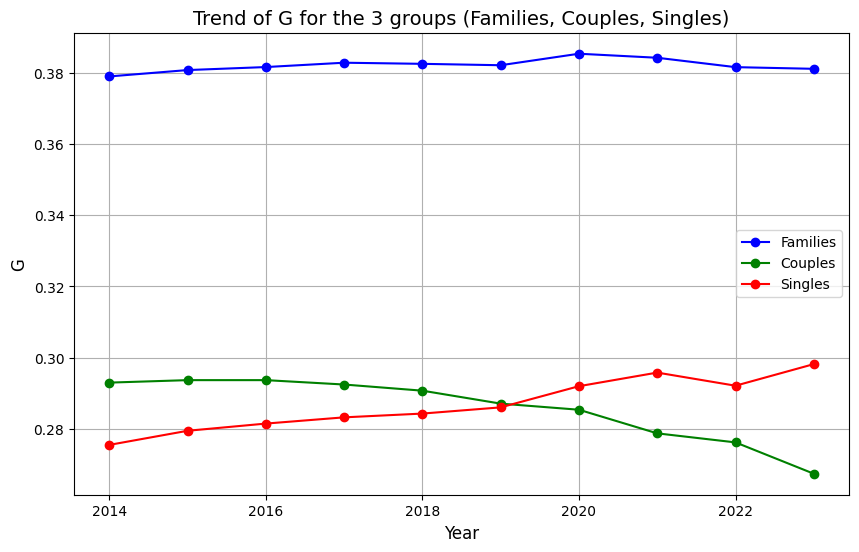

In [6]:
import matplotlib.pyplot as plt

# Filter by the place "All Denmark"
df_all_denmark = df[df['place'] == 'All Denmark']

# Create DataFrames for the three groups
df_families = df_all_denmark[df_all_denmark['group'] == 'Families'].copy()
df_couples = df_all_denmark[df_all_denmark['group'] == 'Couples'].copy()
df_single = df_all_denmark[df_all_denmark['group'] == 'Single'].copy()

# Map the 'income' values to their corresponding numeric values
income_mapping = {
    '<200k': 150000.0,
    '200k-299k': 250000.0,
    '300k-399k': 350000.0,
    '400k-499k': 450000.0,
    '500k-599k': 550000.0,
    '600k-699k': 650000.0,
    '700k-799k': 750000.0,
    '800k-899k': 850000.0,
    '900k-999k': 950000.0,
    '>1M': 1500000.0
}

# Replace the values in the 'income' column
df_families.loc[:, 'income'] = df_families['income'].replace(income_mapping)
df_couples.loc[:, 'income'] = df_couples['income'].replace(income_mapping)
df_single.loc[:, 'income'] = df_single['income'].replace(income_mapping)

# Function to calculate the Gini coefficient values for a DataFrame
def calculate_G(df_group):
    # Filter the row containing totals
    totals = df_group[df_group['income'] == 'Total']

    # Loop over all years from 2014 to 2023
    for year in range(2014, 2024):
        col_totals = totals[str(year)].values[0]  # Total value for the specific year
        f_rel_col = f"f_rel_{year}"  # Name of the new column
        # Calculate the ratio and add the column
        df_group.loc[:, f_rel_col] = df_group[str(year)] / col_totals

    # Reset the DataFrame index
    df_group = df_group.reset_index(drop=True)

    # Loop over all years from 2014 to 2023
    for year in range(2014, 2024):
        x_col = f"X_{year}"  # Name of the new X column
        f_rel_col = f"f_rel_{year}"  # f_rel column for the year

        # Initialize the X column with 0
        df_group.loc[:, x_col] = 0.0

        # Calculate the X value for each row, excluding the "Total" row
        for i in range(1, len(df_group)):  # Start from the second row
            df_group.at[i, x_col] = df_group.at[i, f_rel_col] + df_group.at[i - 1, x_col]

    # Loop over all years from 2014 to 2023
    for year in range(2014, 2024):
        total_income_col = f"total_income_{year}"  # Name of the new column

        # Initialize the total income column with 0
        df_group.loc[:, total_income_col] = 0.0

        # Calculate the total income for each row, excluding "Total"
        for i in range(1, len(df_group)):  # Start from the second row
            df_group.at[i, total_income_col] = df_group.at[i, str(year)] * df_group.at[i, 'income']

    # Calculate the sum of total income for each year from 2014 to 2023
    total_income_by_year = {}

    for year in range(2014, 2024):
        total_income_col = f"total_income_{year}"  # Name of the total income column
        total_income_by_year[year] = df_group[total_income_col].sum()

    # Add the 'f_rel_income_20**' columns for each year from 2014 to 2023
    for year in range(2014, 2024):
        # Name of the 'total_income_20**' column
        total_income_col = f"total_income_{year}"

        # Name of the new 'f_rel_income_20**' column
        f_rel_income_col = f"f_rel_income_{year}"

        # Calculate the values for each row
        df_group.loc[:, f_rel_income_col] = 0  # Initially set all rows to 0
        for i in range(len(df_group)):
            if df_group.loc[i, 'income'] != 'Total':  # If it is not the 'Total' row
                df_group.loc[i, f_rel_income_col] = df_group.loc[i, total_income_col] / total_income_by_year[year]

    # Add the 'Y_20**' columns for each year from 2014 to 2023
    for year in range(2014, 2024):
        # Name of the 'f_rel_income_20**' column
        f_rel_income_col = f"f_rel_income_{year}"

        # Name of the new 'Y_20**' column
        y_col = f"Y_{year}"

        # Set the initial value of the 'Y_20**' column to 0
        df_group.loc[:, y_col] = 0

        # Calculate the values for each row
        for i in range(1, len(df_group)):  # Start from the second row (index 1)
            if df_group.loc[i, 'income'] != 'Total':  # If it is not the 'Total' row
                df_group.loc[i, y_col] = df_group.loc[i, f_rel_income_col] + df_group.loc[i - 1, y_col]

    # Add the 'G_20**' column for each year from 2014 to 2023 and store the Gini values
    G_values = []
    for year in range(2014, 2024):
        # Names of the 'X_20**' and 'Y_20**' columns
        x_col = f"X_{year}"
        y_col = f"Y_{year}"

        # Calculate the sum used to compute the Gini coefficient
        sum_G = 0
        for i in range(1, len(df_group)):  # Start from the second row (index 1)
            X_diff = df_group.loc[i, x_col] - df_group.loc[i - 1, x_col]
            Y_sum = df_group.loc[i, y_col] + df_group.loc[i - 1, y_col]
            sum_G += X_diff * Y_sum

        # Calculate G for the current year
        G_value = 1 - sum_G

        # Add a new 'G_20**' column with the calculated value
        df_group.loc[:, f"G_{year}"] = G_value

        # Add the Gini value to the list for the plot
        G_values.append(G_value)

    return G_values

# Calculate Gini values for each group
G_families = calculate_G(df_families)
G_couples = calculate_G(df_couples)
G_single = calculate_G(df_single)

# Create the plot for the 3 groups
plt.figure(figsize=(10, 6))

plt.plot(range(2014, 2024), G_families, marker='o', label='Families', color='b')
plt.plot(range(2014, 2024), G_couples, marker='o', label='Couples', color='g')
plt.plot(range(2014, 2024), G_single, marker='o', label='Singles', color='r')

# Add labels and title
plt.title('Trend of G for the 3 groups (Families, Couples, Singles)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('G', fontsize=12)
plt.grid(True)
plt.legend()

# Show the plot
plt.show()


The trend of the Gini coefficient differs across the three groups.

For families, the Gini coefficient remains around 0.38, with no major changes compared with 2014. For couples, the Gini coefficient decreased by about 0.02 points over the 10-year period, while for single people it increased by about 0.02 points.

Overall, the Gini coefficient can be considered stable, ranging between 0.28 and 0.38 depending on the group considered, with limited variations.

It is important to emphasize that the calculation is particularly sensitive to the values assigned to the different income brackets. For this reason, it is strongly affected by the initial guesses for the <200k and >1M brackets. In this case, the guesses were 150k and 1.5M.


# Geographical distribution of wealth

The analysis now focuses on the geographical distribution of wealth across Denmark. It may be useful to visualize whether there are geographical regions where the concentration of "millionaires" is higher than the national average.

Historically, the region known as the *Capital Region*, where the Danish capital Copenhagen is located, has generally concentrated higher average levels of wealth than the rest of Denmark. The goal is therefore to verify whether this higher concentration of high incomes, considering for example incomes $>1M$, is not merely a statistical coincidence.

We therefore evaluate the percentage of entities with income above one million Danish kroner for each city. The cities are divided into two sets: cities belonging to the *Capital Region* and cities outside the *Capital Region*. We calculate the average percentage for the two sets and verify whether these two sets of values belong to the same distribution.

Since we do not want to assume that both sets are normally distributed, a simple z-test and the corresponding *p-value* must be excluded as indicators for rejecting the null hypothesis. More generally, the membership of the two sets in different distributions can be tested with a Kolmogorov-Smirnov test.


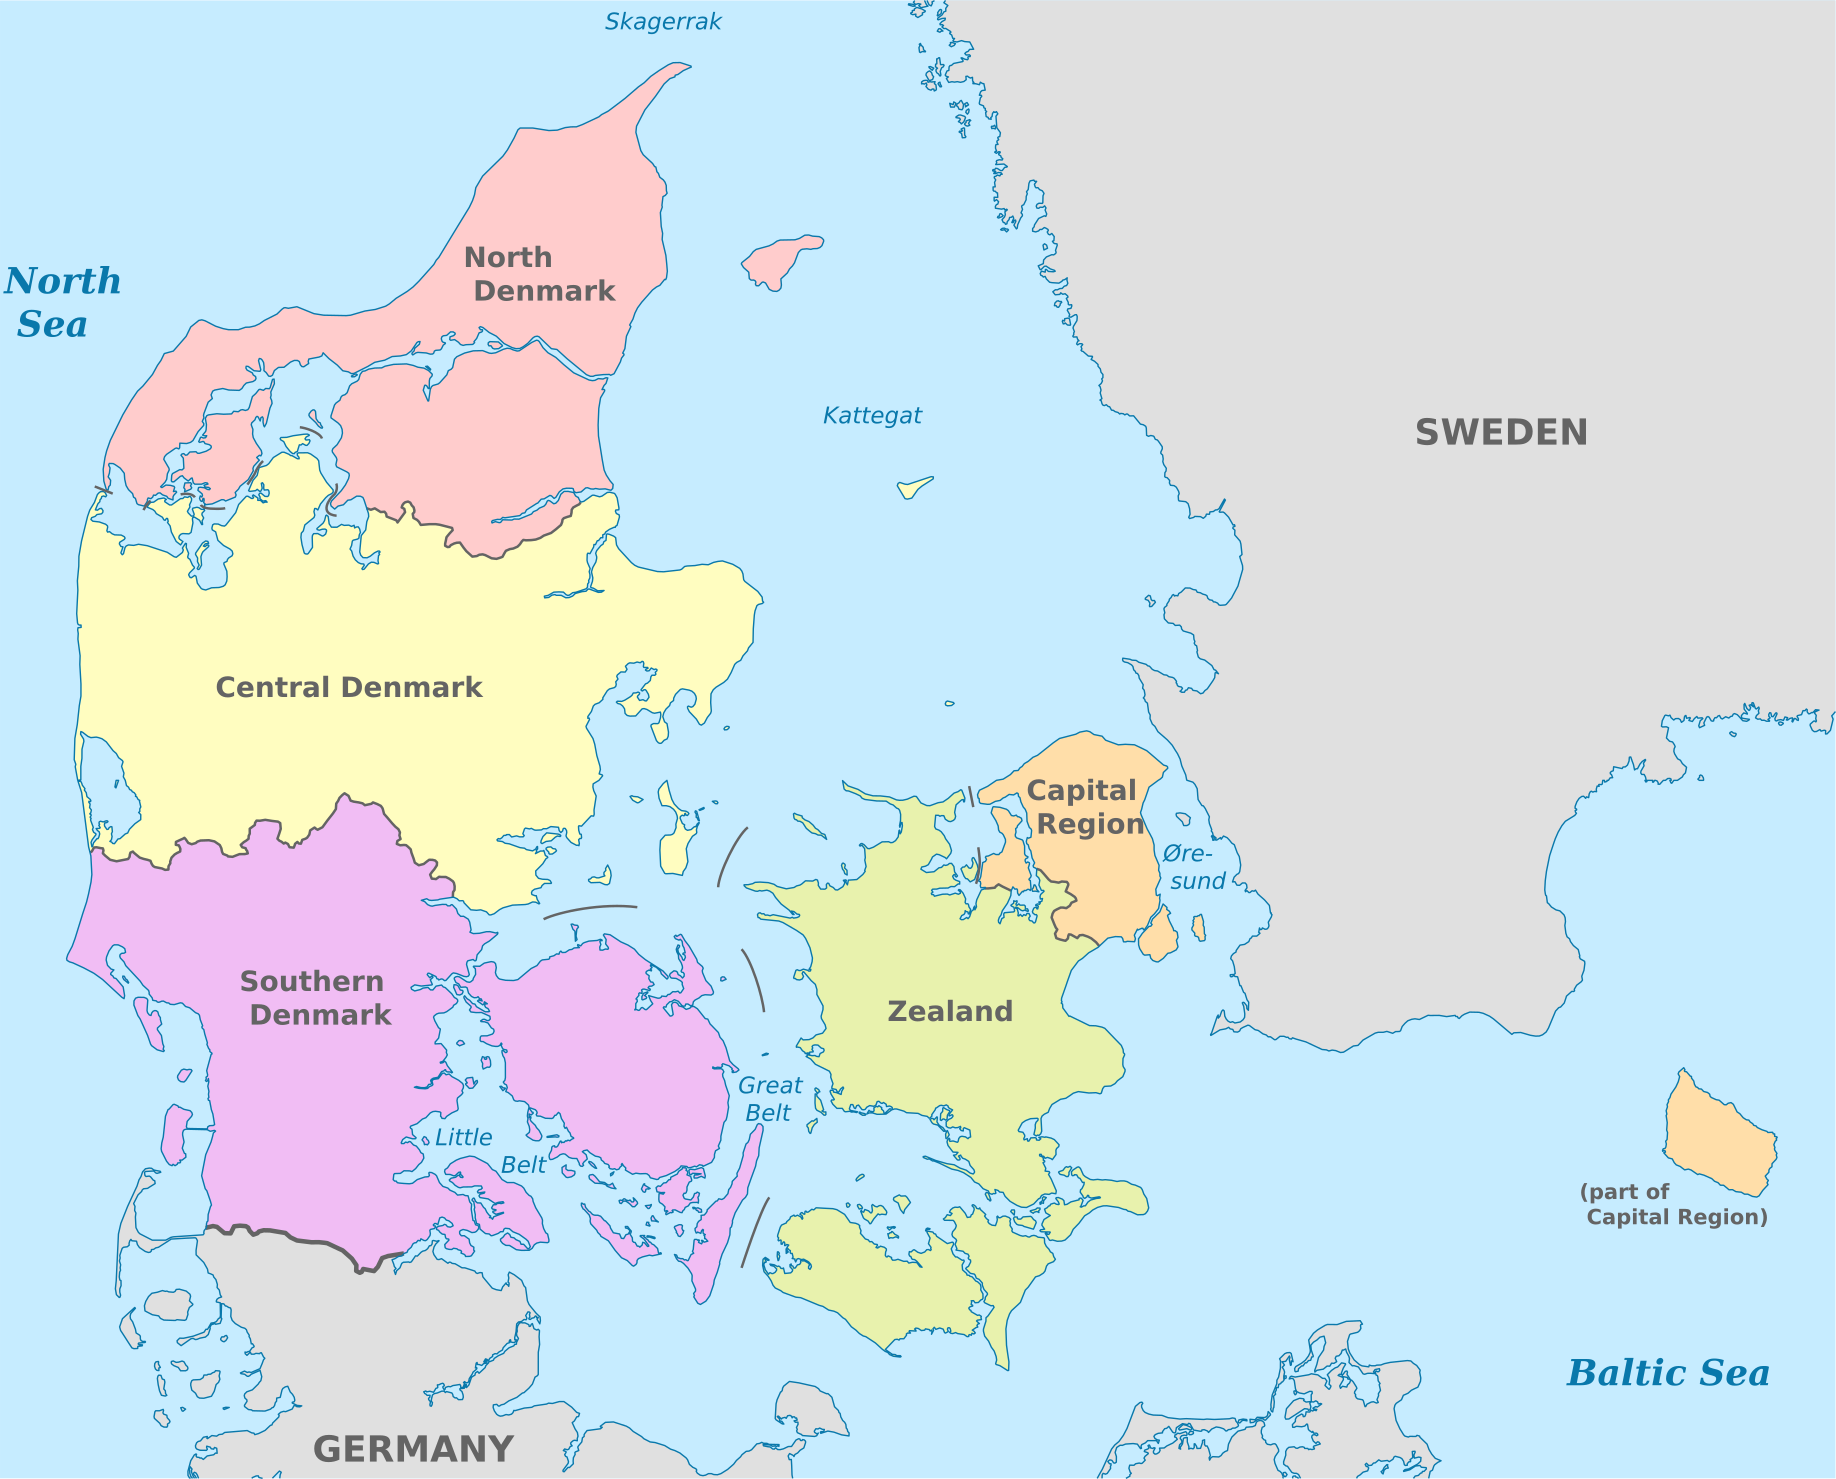

The Capital Region is highlighted in orange in this image


In [7]:
# Load and display the PNG image with reduced dimensions
display(Image(filename='denmark_with_regions.png', width=600))  # You can change the 'width' value as desired
print("The Capital Region is highlighted in orange in this image")


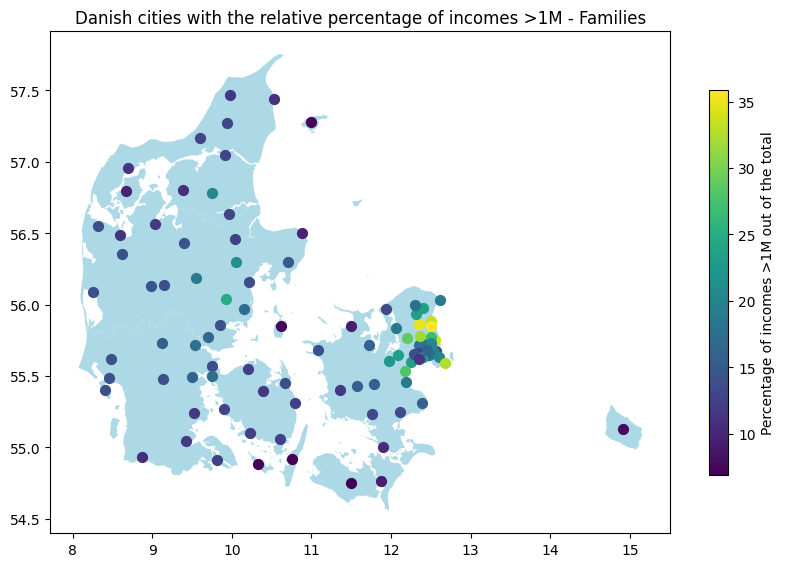

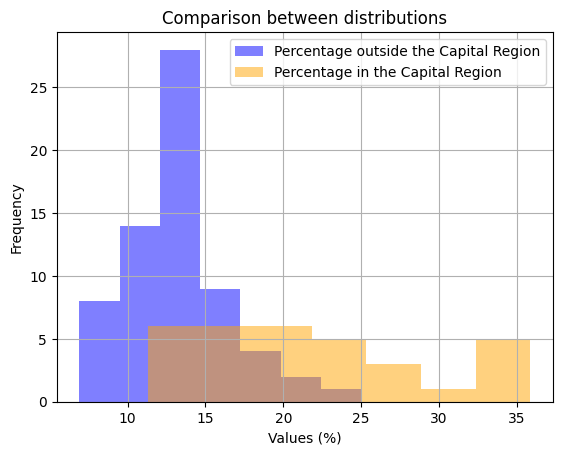

Mean percentage outside the Capital Region: 13.288
Mean percentage in the Capital Region: 21.863
KS statistic: 0.661
p-value: 0.000
The distributions are significantly different.


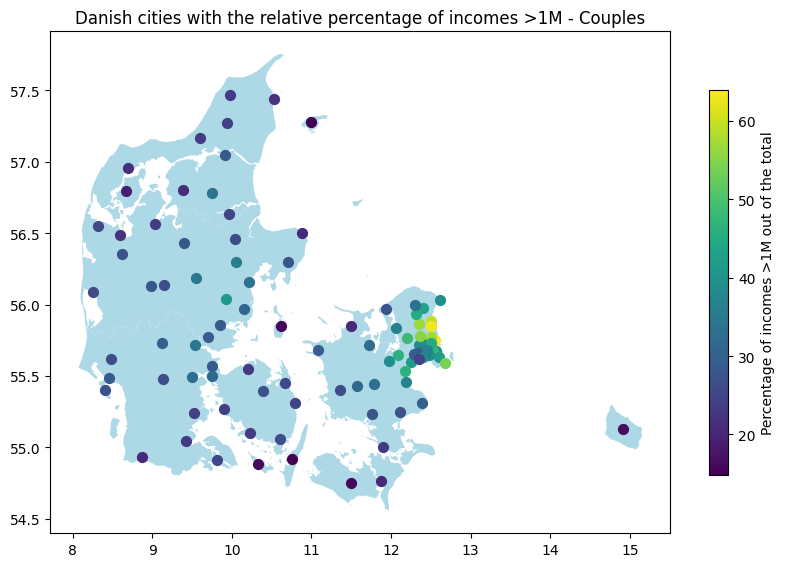

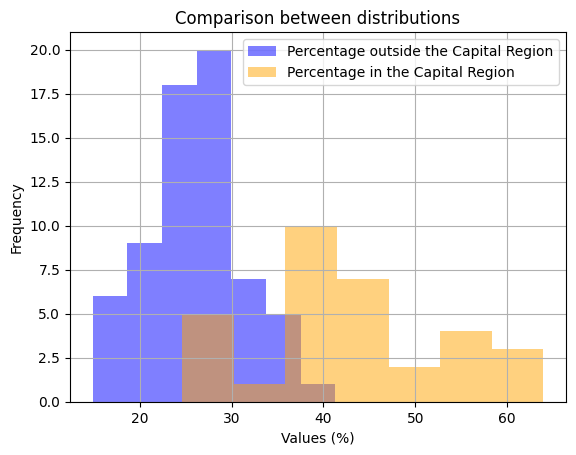

Mean percentage outside the Capital Region: 26.098
Mean percentage in the Capital Region: 42.649
KS statistic: 0.782
p-value: 0.000
The distributions are significantly different.


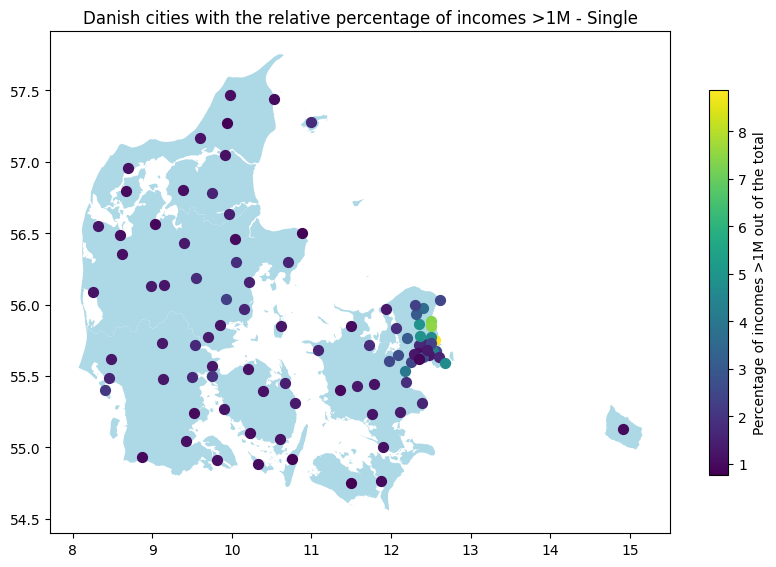

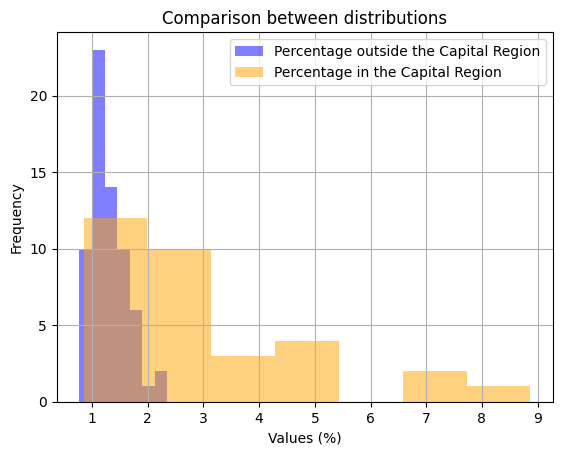

Mean percentage outside the Capital Region: 1.287
Mean percentage in the Capital Region: 3.032
KS statistic: 0.610
p-value: 0.000
The distributions are significantly different.


In [8]:
import geopandas as gpd
import json
from shapely.geometry import Point
from scipy.stats import ks_2samp

def process_group(group_name):
    # Create a DataFrame filtered for the specified group
    df_group = df[df['group'] == group_name]

    # Filter rows corresponding to ">1M" and "Total"
    df_million = df_group[(df_group['income'] == '>1M')]
    df_total = df_group[(df_group['income'] == 'Total')]

    # Merge the two DataFrames on the 'place' column to perform the calculations
    df_merged = pd.merge(df_million[['place', '2023']], df_total[['place', '2023']], on='place', suffixes=('_million', '_total'))

    # Calculate the percentage and add a new column
    df_merged["percentage"] = (df_merged["2023_million"] / df_merged["2023_total"]) * 100

    # Load the GeoJSON file (map of the country)
    geojson_file = 'mappa.geojson'
    gdf = gpd.read_file(geojson_file)

    # Load the city file (dk.json)
    with open('dk.json', 'r') as f:
        cities_data = json.load(f)

    # Extract the list of cities present in the DataFrame
    cities_in_df = df_merged['place'].unique()

    # Get the minimum and maximum percentage values
    min_percent = df_merged['percentage'].min()
    max_percent = df_merged['percentage'].max()

    # Create a list of points from 'dk.json' only for the cities present in the DataFrame
    cities_points = []
    filtered_cities = []
    colors = []
    percentages = []  # List used to store the percentages

    # List used to store the percentages of cities with longitude > 11.8 and latitude > 55.5
    percentages_capital_region = []

    for city in cities_data:
        if city['city'] in cities_in_df and city['lat'] and city['lng']:
            try:
                # Find the percentage associated with the city in the DataFrame
                city_data = df_merged[df_merged['place'] == city['city']].iloc[0]
                percent = city_data['percentage']

                # Normalize the percentage between 0 and 1
                norm_percent = (percent - min_percent) / (max_percent - min_percent)

                # Determine the color based on the percentage
                color = plt.cm.viridis(norm_percent)

                lat = float(city['lat'])
                lng = float(city['lng'])
                city_point = Point(lng, lat)
                cities_points.append(city_point)
                filtered_cities.append(city)
                colors.append(color)
                percentages.append(percent)  # Add the percentage to the list

                # Check whether longitude (lng) is greater than 11.8 and latitude is greater than 55.5, then add the percentage
                if lng > 11.8 and lat > 55.5:
                    percentages_capital_region.append(percent)
            except ValueError:
                print(f"Error converting coordinates for the city: {city['city']}")

    # Create a GeoDataFrame for the filtered cities
    cities_gdf = gpd.GeoDataFrame(filtered_cities, geometry=cities_points)

    # Set the coordinate reference system (CRS) of the map
    cities_gdf.set_crs(gdf.crs, allow_override=True, inplace=True)

    # Plot the map
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(ax=ax, color='lightblue')  # Main map

    # Plot the cities using colors based on the percentage
    for point, color in zip(cities_gdf.geometry, colors):
        ax.scatter(point.x, point.y, color=color, s=50)

    # Add a colorbar to indicate the percentage scale
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=min_percent, vmax=max_percent))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, orientation='vertical', label="Percentage of incomes >1M out of the total", shrink=0.5)

    plt.title(f'Danish cities with the relative percentage of incomes >1M - {group_name}')
    plt.show()

    # Percentage data
    percentages_all = percentages  # Percentages of all plotted cities
    percentages_capital_region = percentages_capital_region  # Percentages of cities belonging to the Capital Region

    # Filter percentages_all to exclude the values present in percentages_capital_region
    percentages_all_filtered = [p for p in percentages_all if p not in percentages_capital_region]

    # Histogram
    plt.hist(percentages_all_filtered, bins=7, alpha=0.5, label='Percentage outside the Capital Region', color='blue')
    plt.hist(percentages_capital_region, bins=7, alpha=0.5, label='Percentage in the Capital Region', color='orange')

    # Plot settings
    plt.xlabel('Values (%)')
    plt.ylabel('Frequency')
    plt.title('Comparison between distributions')
    plt.legend(loc='upper right')
    plt.grid(True)

    # Show the plot
    plt.show()

    # Run the KS test
    ks_stat, p_value = ks_2samp(percentages_all_filtered, percentages_capital_region)
    print(f"Mean percentage outside the Capital Region: {sum(percentages_all_filtered) / len(percentages_all_filtered):.3f}")
    print(f"Mean percentage in the Capital Region: {sum(percentages_capital_region) / len(percentages_capital_region):.3f}")

    # Print the results
    print(f"KS statistic: {ks_stat:.3f}")
    print(f"p-value: {p_value:.3f}")

    # Determine whether the difference is statistically significant
    alpha = 0.05  # Significance level (5%)

    if p_value < alpha:
        print("The distributions are significantly different.")
    else:
        print("There is not enough evidence to state that the distributions are different.")

# Run the process for Families, Couples, and Single
for group in ['Families', 'Couples', 'Single']:
    process_group(group)


For all three groups, it can be qualitatively observed that the average percentages differ substantially.

The KS test states that the distributions are significantly different. This means that the wealth level of Denmark as a whole and that of the *Capital Region* are described differently. Therefore, we conclude that the average concentration of millionaire entities in the *Capital Region* is significantly different from the average concentration in the rest of Denmark.
